# Load in packages to run hydromechanical model and plot

In [40]:
# Load in necessary packages 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as spr
from scipy.sparse.linalg import inv
from pyproj import Proj, transform
import cartopy.feature as cfeature

# Load in thickness-time series data and determine the duration for each site (should be 20,000 years)

In [41]:
# Loading in the interpolated data frame produced in the PreExfiltration.ipynb or PreExfiltrationSpline.ipynb
file_path ='thicknesstimeserieswithfull.csv'
interpolated_df = pd.read_csv(file_path)

# Calculate the duration for each site
duration_tf = interpolated_df.groupby('Site').agg(
    Start_Age=('Age', 'max'),
    End_Age=('Age', 'min'),
    Duration=('Age', lambda x: x.max() - x.min())
).reset_index()

# Display the first few rows of the duration data
duration_tf

,Site,Start_Age,End_Age,Duration
0,1,20000.0,0.0,20000.0
1,2,20000.0,0.0,20000.0
2,3,20000.0,0.0,20000.0
3,4,20000.0,0.0,20000.0
4,5,20000.0,0.0,20000.0
...,...,...,...,...
144,165,20000.0,0.0,20000.0
145,166,20000.0,0.0,20000.0
146,167,20000.0,0.0,20000.0
147,168,20000.0,0.0,20000.0


# Count the number of unique sites in the dataset

In [39]:
num_unique_sites = interpolated_df['Site'].nunique()
num_unique_sites

1

In [23]:
# Set the site number 
site = 61  # Specify the site number
site_data = interpolated_df[interpolated_df['Site'] == site]

# Interpolate thickness data to match the time steps
f_interp = np.interp(t/year, site_data['Age'], site_data['Thickness'])

# Extract latitude and longitude
site_lat = site_data['Latm'].values[0]  # Latitude of the site
site_lon = site_data['Lonm'].values[0]  # Longitude of the site

ValueError: array of sample points is empty

# Parameters

In [24]:
intSave=100
year = 3600*24*365
#xi is dimensionless loading efficiency(Skempton's constant)
xi = 0.2
#rhoi is the density of glacier ice (kg/m3)
rhoi = 920
#rhow is density of water
rhow = 1000
#g is acceleration due to gravity (m/s2)
g = 9.81
#mu_w is the viscosity of water (Pa*s)
mu_w = 1e-3
#S is sediment specific storage capacity (m-1)
S = 1e-4
#permeability
perm=1e-11
#K_t is the hydraulic conductivity (function of perm which we assume stays constant over time)
K_t = perm*rhow*g/mu_w
#Can't find this in the paper, but assuming it has somthing to do 
D = K_t/S
#H_init is the initial thickness of overlying glacier ice (m)
h_init = site_data['Thickness'].max()
# Calculate dh as the total change in ice thickness for the site
dh = site_data['Thickness'].max() - site_data['Thickness'].min()

# Grids and pre-allocation

In [25]:
# Define the length of the domain (L) in meters. In this case, it's 40 km (40,000 meters).
L = 40e3

# Set the number of grid points (nx) to 1001
nx = int(1e3 + 1) # Make it smaller to make the grid coarser 

# Generate a linearly spaced array (x) from 0 to L, with nx points.
# This array represents the spatial coordinates across the domain.
x = np.linspace(0, L, num=nx)

# Calculate the grid spacing (dx) as the difference between consecutive points in the x array.
dx = x[1] - x[0]

# Set a diffusion coefficient (C_D) to 1, which is a dimensionless parameter used in the time step calculation.
C_D = 1

# Calculate the time step (dt) based on the grid spacing (dx) and a given diffusion constant (D).
# The time step is determined by the stability criterion for the diffusion equation.
dt = (dx**2) * C_D / D # Make the time step longer by changing nx.

# Define the total simulation time (tf) in seconds
tf = (site_data['Age'].max() - site_data['Age'].min()) * year #How many years we want the simulation to be 

# Calculate the total number of time steps (nt) based on the total time (tf) and the time step (dt).
# The result is rounded and then increased by 1 to account for the initial time step.
#nt = int(np.round(tf / dt) + 1)
nt = len(site_data)

# Generate a linearly spaced array (t) from 0 to tf, with nt points.
# This array represents the time steps across the entire simulation period.
#t = np.linspace(0, tf, num=nt) # Vector that goes over the years you want to simulate. 
t = site_data['Age'].values * year 

# Initialize the hydraulic pressure head (h) within the sediment.
# The initial head (h_init) is scaled by the ratio of ice density (rhoi) to water density (rhow)
# and is uniformly applied across the entire domain (nx points).
h = h_init * (rhoi / rhow) * np.ones(nx)

# Create an array (h_all) to store the hydraulic pressure head values at each time step for the entire domain.
# The array has dimensions [nx, int(nt/intSave)+1], where intSave is a variable controlling the frequency of saving data.
h_all = np.zeros([nx, int(nt/intSave) + 1])

# Store the initial hydraulic pressure head (h) in the first column of h_all.
h_all[:, 0] = h

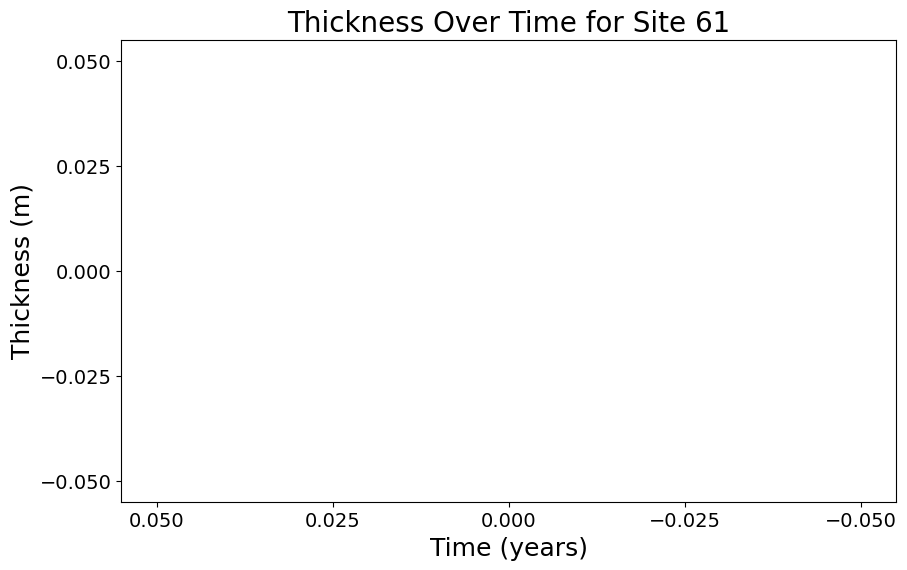

In [26]:
#this is where we'll change the time domain to geologic timescales-so eventually 20,000 years 
#ramp_time = 20 #in years

# Initialize an array to store the ice surface height at different time steps
#hbc_sfc  = np.zeros(int(nt)); #nt is the total number of time steps 
hbc_sfc = site_data['Thickness'].values

#change in ice surface height with time
dhdt = np.zeros_like(hbc_sfc)

# Create boolean masks to identify the time before and after the ramp time
#bramp_bool = t < ramp_time*year #before ramp time
#aramp_bool = t >= ramp_time*year #after ramp time 

# For times before the ramp, linearly decrease the ice surface height from initial height h_init to h_init - dh
#hbc_sfc[bramp_bool] = np.linspace(h_init,h_init-dh,np.count_nonzero(bramp_bool, axis=None))

# For times after the ramp, keep the ice surface height constant at h_init - dh
#hbc_sfc[aramp_bool] = h_init-dh;

# Calculate the rate of change of ice surface height over time by taking the difference between consecutive time steps
dhdt[1:] = np.diff(hbc_sfc)/dt

#Optional: Uncommenting the following lines would instead set dhdt to a linear decrease over the ramp period
#dhdt[bramp_bool] = -np.linspace(0,2*dh/ramp_time,np.count_nonzero(bramp_bool, axis=None))/year
#hbc_sfc = h_init + np.cumsum(dhdt*dt)

plt.figure(figsize=(10, 6))
plt.plot(site_data['Age'], site_data['Thickness'], color='blue')
plt.xlabel('Time (years)', fontsize=18)  # Increase the font size
plt.ylabel('Thickness (m)', fontsize=18)  # Increase the font size
plt.title(f'Thickness Over Time for Site {site}', fontsize=20)  # Increase the font size
plt.gca().invert_xaxis()  # Invert x-axis so that time decreases to the right

# Customize ticks
plt.xticks(fontsize=14)  # Set x-axis tick font size
plt.yticks(fontsize=14)  # Set y-axis tick font size

# Reduce the number of ticks
plt.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
plt.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

plt.show()

# Solve with Crank-Nicolson method

In [27]:
# Initialize a 3x(nx) matrix filled with zeros to store the diagonals for the left-side matrix (Ml)
Mld = np.zeros([3,nx])

# Set the first and third rows of the matrix to be -0.5*C_D for all columns
Mld[0, :] = -0.5 * C_D * np.ones(nx)  # Upper diagonal
Mld[2, :] = -0.5 * C_D * np.ones(nx)  # Lower diagonal

# Set the second row of the matrix to be (1+C_D) for all columns
Mld[1, :] = (1 + C_D) * np.ones(nx)  # Main diagonal

# Create a sparse matrix (Ml) using the diagonals in Mld with offsets -1, 0, and 1
Ml = spr.spdiags(Mld, [-1, 0, 1], nx, nx)

# Convert the sparse matrix to a compressed sparse column format for efficient arithmetic and matrix-vector operations
Ml = spr.csc_matrix(Ml)

# Modify specific elements in the sparse matrix to enforce boundary conditions
Ml[-1, -1] = 1 + 0.5 * C_D  # Adjust the last element on the main diagonal
Ml[0, 1] = 0  # Set the first off-diagonal element to zero
Ml[0, 0] = 1  # Set the first element on the main diagonal to one

# Compute the inverse of the left-side matrix (Ml)
iMl = inv(Ml)

# Initialize a 3x(nx) matrix filled with zeros to store the diagonals for the right-side matrix (Mr)
Mrd = np.zeros([3, nx])

# Set the first and third rows of the matrix to be 0.5*C_D for all columns
Mrd[0, :] = 0.5 * C_D * np.ones(nx)  # Upper diagonal
Mrd[2, :] = 0.5 * C_D * np.ones(nx)  # Lower diagonal

# Set the second row of the matrix to be (1-C_D) for all columns
Mrd[1, :] = (1 - C_D) * np.ones(nx)  # Main diagonal

# Create a sparse matrix (Mr) using the diagonals in Mrd with offsets -1, 0, and 1
Mr = spr.spdiags(Mrd, [-1, 0, 1], nx, nx)

# Convert the sparse matrix to a compressed sparse column format for efficient arithmetic and matrix-vector operations
Mr = spr.csc_matrix(Mr)

# Modify specific elements in the sparse matrix to enforce boundary conditions
Mr[-1, -1] = 1 - 0.5 * C_D  # Adjust the last element on the main diagonal
Mr[0, 1] = 0  # Set the first off-diagonal element to zero
Mr[0, 0] = 1  # Set the first element on the main diagonal to one

/opt/anaconda3/envs/polartoolkit/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


In [28]:
# Loop through each time step from 0 to nt-2 (nt-1 in zero-indexed Python)
for k in np.arange(nt-1):
    # Create a copy of the current ice thickness (h) and reshape it into a column vector (nx, 1)
    hm = h
    hm.shape = (nx, 1)

    # Apply boundary condition: Set the surface height at the first grid point to the surface height at this time step
    # adjusted by the ratio of ice density (rhoi) to water density (rhow)
    h[0] = hbc_sfc[k] * (rhoi / rhow)

    # Initialize a source vector (Svec) with zeros, used to apply the source term from the thinning rate
    Svec = np.zeros([nx, 1])

    # Apply the source term (related to thinning rate) to the interior points of the grid
    Svec[1:-2] = dt * xi * (rhoi / rhow) * dhdt[k]

    # Compute the new ice thickness (hnew) by applying the inverse of the left-side matrix (iMl)
    # to the matrix-vector product of the right-side matrix (Mr) and the current ice thickness (hm), 
    # and adding the source term vector (Svec)
    hnew = iMl.dot(Mr.dot(hm) + Svec)

    # Save the computed ice thickness at intervals specified by intSave
    if k % intSave == 0:
        h_all[:, int(k/intSave)] = np.transpose(hnew)

    # Update the ice thickness (h) to the newly computed values for the next iteration
    h = hnew

# Plot numerical against analytical solution (idealized thinning-no ramp time)

In [29]:
# #import numpy as np
# import matplotlib.pyplot as plt

# # -----------------------------------------------------------------
# # Example parameters (adjust as needed)
# # -----------------------------------------------------------------
# time_yr = np.linspace(0, 5, 100)    # time from 0 to 5 years
# constant_flux_value = 5.0          # mm/day (example)
# # -----------------------------------------------------------------

# # 1) Define a constant time series instead of a ramp
# #    In your original code, you may have something like ramp_timeyear
# #    or t_ramp. Just remove or set that to 0 and use a constant factor.
# x_bramp = 1.0  # No time dependence now

# # 2) If your original infiltration/exfiltration flux was something like:
# #    tsurf_mbc_fluxweq = <some expression of infiltration>
# #    Then we simply set it to a constant array:
# tsurf_mbc_fluxweq = np.full_like(time_yr, constant_flux_value)

# # 3) For the "analytic" flux, do the same if you want a flat, constant line:
# sflux_an_delta = np.full_like(time_yr, constant_flux_value)

# # -----------------------------------------------------------------
# # Plotting
# # -----------------------------------------------------------------
# plt.figure(figsize=(8,6))

# # Numerical solution (now constant in time)
# plt.plot(time_yr, tsurf_mbc_fluxweq * x_bramp,
#          color='black', linewidth=3, label="Numerical (Constant)")

# # Analytic solution (also constant)
# plt.plot(time_yr, sflux_an_delta,
#          color='red', linewidth=3, label="Analytic (Constant)")

# plt.legend()
# plt.xlim([0, 5])
# plt.ylim([0, 10])
# plt.xlabel('Time (years)', fontsize=14)
# plt.ylabel('Exfiltration Flux (mm/day)', fontsize=14)
# plt.title("No Ramp Time, Constant Flux", fontsize=16)

# plt.savefig("Exfil_NumericalDiff_1DPanel_noRamp.png", bbox_inches='tight')
# plt.show()

In [30]:
# # Calculate the surface flux (sfc_flux) by taking the difference between the first two layers of the ice thickness (h_all)
# # and multiplying by the thermal conductivity (K_t) divided by the grid spacing (dx).
# # The result is transposed to match the expected shape for further use.
# sfc_flux = np.transpose(K_t * (h_all[0, :] - h_all[1, :]) / dx)

# # Calculate the analytical surface flux (sflux_an) based on the thinning rate (dhdt),
# # the thermal conductivity (K_t), a scaling factor (S), and the current time (t).
# # This formula assumes a simplified analytical model for heat transfer in the ice.
# sflux_an = 2 * (1 - xi) * (rhoi / rhow) * dhdt[1] * (K_t * S * t / np.pi) ** 0.5

# # Calculate the analytical surface flux for a small time increment (sflux_an_delta),
# # which represents the surface flux at a specific time step based on the thinning rate (dh),
# # the thermal conductivity (K_t), a scaling factor (S), and the current time (t).
# sflux_an_delta = (1 - xi) * (rhoi / rhow) * dh * (K_t * S / (np.pi * t)) ** 0.5

# # Extract a subset of the time array (tsub) at intervals specified by intSave.
# # This is used to reduce the number of time points when plotting or analyzing the data.
# tsub = t[0:-1:intSave]

# # Create a boolean mask (t_bramp) to identify time points before the ramp period.
# # This is used to differentiate between time periods in the simulation.
# #t_bramp = t < ramp_time * year

In [31]:
# # Plot the numerical solution for the surface flux (sfc_flux) over time.
# # The flux is converted from its original units to mm/a by multiplying by -1000 and scaling by the time step (year).
# # The plot uses black 'x' markers with a line width of 3 and labels the plot as "Numerical Solution".
# plt.plot(tsub / year, -1000 * sfc_flux * year, 'x', color='black', linewidth=3, label="Numerical Solution")

# # Plot the analytical solution for the constant surface flux (sflux_an) over the time before the ramp period (t_bramp).
# # The plot uses a cyan solid line with a line width of 3 and labels it as "$q_c$".
# #plt.plot(t[t_bramp] / year, -1000 * sflux_an[t_bramp] * year, '-', color='cyan', linewidth=3, label="$q_c$")

# # Plot the analytical solution for the surface flux change (sflux_an_delta) starting from the second time step.
# # The plot uses a red solid line with a line width of 3 and labels it as "$q_d$".
# # The time is shifted by half of the ramp time to align with the expected behavior.
# plt.plot(t[1:] / year + ramp_time / 2, 1000 * sflux_an_delta[1:] * year, '-', color='red', linewidth=3, label="$q_d$")

# # Fill a vertical region on the plot between 0 and 20 years with a light black color (gray) to indicate a specific time period.
# # The alpha parameter controls the transparency of the filled area.
# plt.fill_betweenx([0, 16], 0, 20, color='k', alpha=0.1)

# # Label the x-axis as "Time (a)", where 'a' stands for years, and set the font size to 18.
# plt.xlabel('Time (a)', fontsize=18)

# # Label the y-axis as "Exfiltration Flux (mm/a)", with the flux in millimeters per year, and set the font size to 18.
# plt.ylabel('Exfiltration Flux (mm/a)', fontsize=18)

# # Display the legend on the plot, which will include the labels specified in the plot commands.
# plt.legend()

# # Set the limits of the y-axis from 0 to 15 to focus on the range of interest for the flux.
# plt.ylim(0, 15)

# # Set the limits of the x-axis from 0 to 100 years to focus on the relevant time period.
# plt.xlim(0, 100)

# # (Optional) Save the plot as a PDF file named 'Exfil_NumericalDiff_TimeDepLoad_1panel_v4.pdf' with tight bounding box.
# # The format is set to PDF to preserve the quality of the plot.
# # plt.savefig('Exfil_NumericalDiff_TimeDepLoad_1panel_v4.pdf', bbox_inches='tight', format='pdf')



# Load in packages to extract relevant field

In [32]:
import xarray as xr
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors
import cmocean
import scipy.io as sio
import geopandas as gpd
import rioxarray
import zipfile

# Calculate Exfiltration Prediction

In [33]:
# Constants
year = 3600 * 24 * 365  # seconds in a year
rhoi = 920  # density of glacier ice (kg/m3)
rhow = 1000  # density of water (kg/m3)
g = 9.81  # acceleration due to gravity (m/s2)
mu_w = 1e-3  # viscosity of water (Pa*s)
perm = 1e-11  # permeability (m^2)
K_t = perm * rhow * g / mu_w  # hydraulic conductivity (m/s)
S = 1e-4  # sediment specific storage capacity (m-1)
xi = 0.2  # Skempton's constant (dimensionless)
deltat = (site_data['Age'].max() - site_data['Age'].min()) * year  # time increment based on the site's age range

# Calculate dhdt (rate of change of ice thickness)
dhdt = np.gradient(site_data['Thickness'], site_data['Age'] * year)

# Calculate the exfiltration rate for the selected site
exfil_analytic = 2 * (1 - xi) * (rhoi / rhow) * dhdt * (K_t * S * deltat / np.pi) ** 0.5
exfil_value = exfil_analytic * 1000  # Convert to mm/yr

# Plot the exfiltration rate over time
plt.figure(figsize=(10, 6))
plt.plot(site_data['Age'], exfil_value, 'o-', color='blue')
plt.xlabel('Time (years)', fontsize=18)  # Increase the font size
plt.ylabel('Exfiltration Rate (mm/yr)', fontsize=18)  # Increase the font size
plt.title(f'Exfiltration Rate for Site {site}', fontsize=20)  # Increase the font size
plt.gca().invert_xaxis()  # Invert x-axis so that time decreases to the right

# Customize ticks
plt.xticks(fontsize=14)  # Set x-axis tick font size
plt.yticks(fontsize=14)  # Set y-axis tick font size

# Reduce the number of ticks
plt.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
plt.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis
plt.legend()
#plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

NameError: name 'exfil_value' is not defined

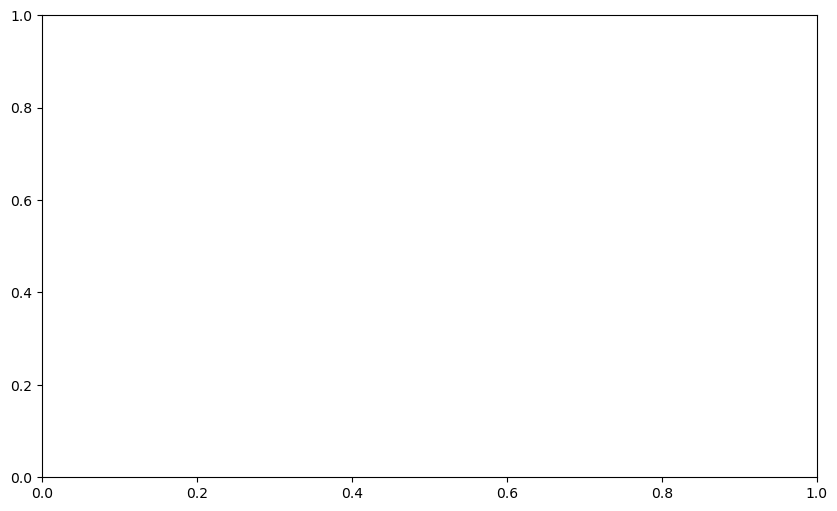

In [34]:
# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Set a consistent line width
line_width = 5

# Plot the exfiltration rate on the primary y-axis
line1, = ax1.plot(site_data['Age'], exfil_value, '-', color='#D55E00', label='Exfiltration Rate', linewidth=line_width)
ax1.set_xlabel('Time (years)', fontsize=18)
ax1.set_ylabel('Exfiltration Rate (mm/yr)', fontsize=18, color='#D55E00')
ax1.tick_params(axis='y', labelsize=14, colors='#D55E00')
ax1.invert_xaxis()  # Invert x-axis so that time decreases to the right
ax1.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
ax1.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

# Create a secondary y-axis for thickness
ax2 = ax1.twinx()
line2, = ax2.plot(site_data['Age'], site_data['Thickness'], color='#0072B2', label='Thickness', linewidth=line_width)
ax2.set_ylabel('Thickness (m)', fontsize=18, color='#0072B2')
ax2.tick_params(axis='y', labelsize=14, colors='#0072B2')
ax2.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

# Combine legends and place it in the upper right
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=14)

# Set title
plt.title(f'', fontsize=15)
plt.savefig("exfiltration_thickness_plot.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()

In [35]:
# Calculate and print exfiltration value for a singular site 

# Ensure exfil_value is a Pandas Series indexed by site_data index
exfil_series = pd.Series(exfil_value, index=site_data.index)

# Iterate over sites
for site in site_data['Site'].unique():
    site_mask = site_data['Site'] == site
    site_exfil = exfil_series.loc[site_mask]  # Correct indexing method
    mean_exfiltration = site_exfil.mean()
    total_exfiltrated_volume = np.sum((site_exfil / 1000) * 20000)  # Convert mm to m and multiply by duration)
    
    # Print results for each site
    print(f'Site {site}:')
    print(f'  Mean Exfiltration Rate: {mean_exfiltration:.6f} mm/yr')

NameError: name 'exfil_value' is not defined

In [36]:
# Calculate and store exfiltration values for all the sites

# Initialize an empty DataFrame to store exfiltration values
time_steps = interpolated_df['Age'].unique()
exfiltration_df = pd.DataFrame(index=interpolated_df.index, columns=['Site', 'Age', 'Latitude', 'Longitude', 'Exfiltration (mm/yr)'])

# Ensure exfil_value is reset before looping over sites
exfil_value = None  

for site in interpolated_df['Site'].unique():
    site_data = interpolated_df[interpolated_df['Site'] == site]

    # Compute site-specific deltat
    deltat = (site_data['Age'].max() - site_data['Age'].min()) * year

    # Calculate dhdt (rate of change of ice thickness)
    dhdt = np.gradient(site_data['Thickness'], site_data['Age'] * year)

    # Calculate the exfiltration rate
    exfil_analytic = 2 * (1 - xi) * (rhoi / rhow) * dhdt * (K_t * S * deltat / np.pi) ** 0.5
    exfil_value = exfil_analytic * 1000  # Convert to mm/yr

    # Extract latitude and longitude
    site_lat = site_data['Latm'].iloc[0]
    site_long = site_data['Lonm'].iloc[0]

    # Store values in DataFrame
    exfiltration_df.loc[site_data.index, 'Site'] = site
    exfiltration_df.loc[site_data.index, 'Age'] = site_data['Age']
    exfiltration_df.loc[site_data.index, 'Latitude'] = site_lat
    exfiltration_df.loc[site_data.index, 'Longitude'] = site_long
    exfiltration_df.loc[site_data.index, 'Exfiltration (mm/yr)'] = exfil_value

# Convert columns to appropriate data types
exfiltration_df['Site'] = exfiltration_df['Site'].astype(str)
exfiltration_df['Age'] = exfiltration_df['Age'].astype(float)
exfiltration_df['Latitude'] = exfiltration_df['Latitude'].astype(float)
exfiltration_df['Longitude'] = exfiltration_df['Longitude'].astype(float)
exfiltration_df['Exfiltration (mm/yr)'] = exfiltration_df['Exfiltration (mm/yr)'].astype(float)

# Calculate the max exfiltration value and corresponding age per site
max_exfiltration_info = (
    exfiltration_df.loc[
        exfiltration_df.groupby('Site')['Exfiltration (mm/yr)'].idxmax()
    ][['Site', 'Age', 'Exfiltration (mm/yr)']]
    .rename(columns={
        'Age': 'Age of Max Exfiltration (yr)',
        'Exfiltration (mm/yr)': 'Max Exfiltration (mm/yr)'
    })
    .reset_index(drop=True)
)

# Display the full exfiltration values and the summary
#display(exfiltration_df)
#display(max_exfiltration_info)

# Save the max exfiltration summary to CSV
max_exfiltration_info.to_csv('max_exfiltration_per_site.csv', index=False)
exfiltration_df.to_csv('full_exfiltration_timeseries.csv', index=False)


# Results Figures


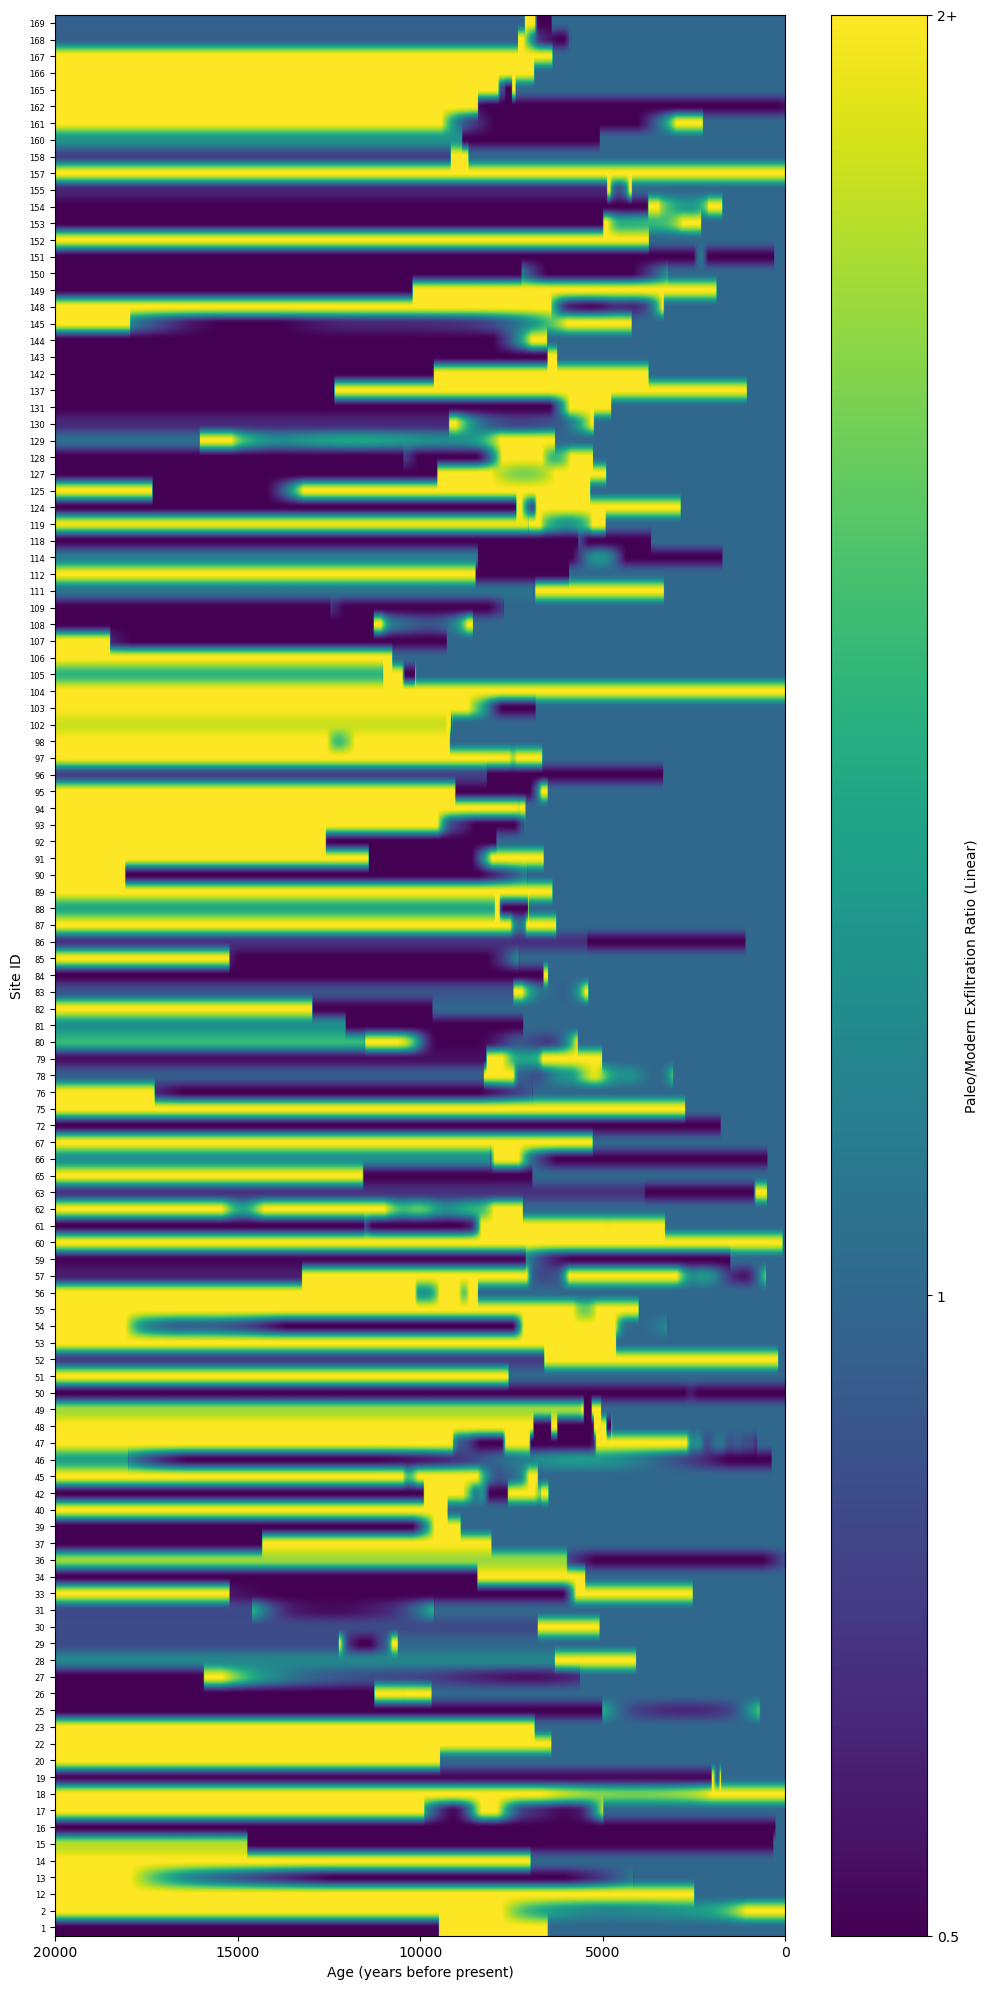

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Load dataset
df = pd.read_csv("full_exfiltration_timeseries.csv")

# Filter out sites with no valid modern exfiltration (Age 0 <= 0 or NaN)
modern_data = df[df['Age'] == 0].copy()

# Drop entries with missing or non-positive exfiltration at modern
invalid_sites = modern_data[modern_data['Exfiltration (mm/yr)'] <= 0]['Site']
invalid_sites = set(invalid_sites.values)  # set of site IDs to remove
df_valid = df[~df['Site'].isin(invalid_sites)].copy()

# Compute modern exfiltration series for valid sites
modern_series = df_valid[df_valid['Age'] == 0].set_index('Site')['Exfiltration (mm/yr)']

# Calculate paleo/modern ratio for each entry
df_valid['ModernEx'] = df_valid['Site'].map(modern_series)
df_valid['Ratio'] = df_valid['Exfiltration (mm/yr)'] / df_valid['ModernEx']

# Pivot data to matrix form (Site vs Age) for heatmaps
ratio_matrix = df_valid.pivot(index='Site', columns='Age', values='Ratio')

# Ensure columns (ages) are in numeric order
ratio_matrix = ratio_matrix.sort_index(axis=1)  # sort ages ascending

# --- Heatmap 1: Linear scale (ratio 0.5 to

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Load dataset
df = pd.read_csv("full_exfiltration_timeseries.csv")

# Filter to sites with valid modern exfiltration (Age 0 > 0)
modern = df[df['Age'] == 0]
valid_sites = modern[modern['Exfiltration (mm/yr)'] > 0]['Site']
df_valid = df[df['Site'].isin(valid_sites)].copy()

# Compute modern exfiltration per site and add paleo/modern ratio
modern_series = modern.set_index('Site')['Exfiltration (mm/yr)']
df_valid['Ratio'] = df_valid['Exfiltration (mm/yr)'] / df_valid['Site'].map(modern_series)

# Pivot to matrix for heatmaps (Site vs Age)
ratio_matrix = df_valid.pivot(index='Site', columns='Age', values='Ratio')
ratio_matrix = ratio_matrix.sort_index(axis=1)  # ensure ages sorted ascending

# Heatmap 1: Linear scale (0.5–2 range)
# Increase figure height to spread out site labels
fig1, ax1 = plt.subplots(figsize=(10, 20))  # was (10, 8)

# Plot heatmap with all site labels
im1 = ax1.imshow(np.clip(ratio_matrix, 0.5, 2), origin='lower', aspect='auto',
                 vmin=0.5, vmax=2, cmap='viridis')
ax1.set_xlabel("Age (years before present)")
ax1.set_ylabel("Site ID")

# Set x-axis tick labels for selected ages
age_ticks = [0, 5000, 10000, 15000, 20000]
ages = ratio_matrix.columns.to_numpy(float)
ax1.set_xticks([np.where(ages == t)[0][0] for t in age_ticks if t in ages])
ax1.set_xticklabels([str(t) for t in age_ticks if t in ages])

# Set y-axis tick labels for all sites
site_ids = ratio_matrix.index.to_list()
yticks = np.arange(len(site_ids))
ax1.set_yticks(yticks)
ax1.set_yticklabels(site_ids)
ax1.tick_params(axis='y', labelsize=6)  # smaller font if needed

ax1.invert_xaxis()  # past on left, present on right

# Colorbar
cbar1 = fig1.colorbar(im1, ax=ax1)
cbar1.set_label("Paleo/Modern Exfiltration Ratio (Linear)")
cbar1.set_ticks([0.5, 1, 2])
cbar1.set_ticklabels(['0.5', '1', '2+'])

fig1.tight_layout()
fig1.savefig("heatmap_linear_all_sites.png", dpi=300)

# Mapping Results

In [26]:
%%capture
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


from polartoolkit import fetch, maps, regions, utils

In [27]:
# layer_names = [
#     # topographies
#     "surface",
#     "icebase",
#     "bed",
#     # thicknesses
#     "ice_thickness",
#     "water_thickness",
#     # uncertainties
#     "bed_uncertainty",
#     "ice_thickness_uncertainty",
#     # others
#     "mask",
# ]

# grids = []
# for name in layer_names:
#     data = fetch.bedmap3(
#         layer=name,
#         # available options
#         # reference ("eigen-gl04c" or "ellipsoid")
#         # region,
#         # spacing,
#         # registration ("g" for gridline or "p" for pixel),
#         # fill_nans (True or False),
#     )
#     grids.append(data)
#     print(f"Info for {name}")
#     _ = utils.get_grid_info(data, print_info=True)
#     # print("##########")

# Ensure sites are plotting where they are supposed to

In [28]:
# # Load Bedmap3 ice thickness layer
# ice_thickness = fetch.bedmap3(layer="bed")

# # Get metadata and print it if you want
# _ = utils.get_grid_info(ice_thickness, print_info=True)

# # Define the projection for the plot
# projection = ccrs.SouthPolarStereo()

# # Create a new figure
# fig = plt.figure(figsize=(16, 16))
# ax = plt.subplot(1, 1, 1, projection=projection)

# # Plot the ice thickness background
# ice_thickness.plot.pcolormesh(
#     ax=ax,
#     transform=ccrs.SouthPolarStereo(),
#     robust=True,
#     cmap="Blues",
#     #cbar_kwargs={"label": "Ice Thickness (m)"},
# )

# # Add land and ocean features to show the full continent
# ax.add_feature(cfeature.LAND, facecolor='white', zorder=0)
# ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
# ax.add_feature(cfeature.COASTLINE, edgecolor='black')
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# ## Get unique site locations
# unique_sites = exfiltration_df[['Site', 'Latitude', 'Longitude']].drop_duplicates()

# # Plot each site with label
# for _, row in unique_sites.iterrows():
#     site_lat = row["Latitude"]
#     site_lon = row["Longitude"]
#     site_number = row["Site"]

#     ax.scatter(site_lon, site_lat, color='red', s=100, marker='o', edgecolor='black',
#                transform=ccrs.PlateCarree(), zorder=10)
#     #ax.text(site_lon, site_lat, str(site_number), fontsize=12, color='black',
#             #transform=ccrs.PlateCarree(), ha='left', va='bottom', fontweight='bold')


# # Add gridlines with labels
# gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
# gl.top_labels = True
# gl.right_labels = True

# # Set extent to Antarctica
# ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# # Save figure
# plt.savefig('SiteMap_with_bed.jpeg', format='jpeg', bbox_inches='tight', dpi=300)
# plt.show()


# Map Figure for Publication 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import rioxarray as rxr

# Load Bedmap3 mask from TIFF file
ice_thickness = rxr.open_rasterio("bm3_masks.tif", masked=True).squeeze()

# Load hydropotential layer
ds = xr.open_dataset("Antarctic_hydropotential.nc")
hydropotential = ds['hydropotential']

# Define main projection
projection = ccrs.SouthPolarStereo()

# Create figure and main axis
fig = plt.figure(figsize=(1, 12))
ax_main = plt.subplot(1, 1, 1, projection=projection)

# Plot ice mask from TIFF
ice_thickness.plot(
    ax=ax_main,
    transform=ccrs.PlateCarree(),  # assuming TIFF is in EPSG:4326
    cmap="Blues",
    robust=True,
    add_colorbar=False
)

# Add base features
ax_main.add_feature(cfeature.LAND, facecolor='white', zorder=0)
ax_main.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
ax_main.add_feature(cfeature.COASTLINE, edgecolor='black')
ax_main.add_feature(cfeature.BORDERS, linestyle=':')

# Plot site markers on main map
unique_sites = exfiltration_df[['Site', 'Latitude', 'Longitude']].drop_duplicates()
for _, row in unique_sites.iterrows():
    ax_main.scatter(row["Longitude"], row["Latitude"], color='red', s=100, marker='o',
                    edgecolor='black', transform=ccrs.PlateCarree(), zorder=10)

# Grid and extent
gl = ax_main.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = True
gl.right_labels = True
ax_main.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

# Inset definitions: [fig_coords], [extent], "label", (center_lon, center_lat)
inset_definitions = [
    ([0.02, 0.02, 0.18, 0.18], [245, 258, -83.5, -75], "Amundsen", (251.5, -79.25)),
    ([0.80, 0.80, 0.18, 0.18], [298, 304, -69.5, -64.5], "Peninsula", (301, -67)),
    ([0.80, 0.02, 0.18, 0.18], [300, 312, -87.5, -79], "Ronne", (306, -83.25)),
    ([0.02, 0.80, 0.18, 0.18], [65, 80, -75, -67], "Amery", (72.5, -71)),
    ([0.30, 0.02, 0.18, 0.18], [190, 205, -84, -77], "Siple", (197.5, -80.5)),
    ([0.50, 0.80, 0.18, 0.18], [160, 170, -78, -72], "Victoria", (165, -75)),
]

# Draw each inset
for pos, extent, label, (cx, cy) in inset_definitions:
    inset_ax = fig.add_axes(pos, projection=ccrs.SouthPolarStereo())

    # Plot hydropotential
    hydropotential.plot(
        ax=inset_ax,
        transform=ccrs.SouthPolarStereo(),
        cmap='viridis',
        robust=True,
        add_colorbar=False
    )
    inset_ax.set_extent(extent, crs=ccrs.PlateCarree())
    inset_ax.add_feature(cfeature.LAND, facecolor='white', zorder=0)
    inset_ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
    inset_ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)

    # Plot site dots in inset
    for _, row in unique_sites.iterrows():
        inset_ax.scatter(row["Longitude"], row["Latitude"], color='red', s=30, marker='o',
                         edgecolor='black', transform=ccrs.PlateCarree(), zorder=10)

    # Add label
    inset_ax.set_title(label, fontsize=9)

# Save and show
plt.savefig('SiteHPMapPub.jpeg', format='jpeg', dpi=300, bbox_inches='tight')
plt.show(block=True)


KeyboardInterrupt: 

Exception ignored in: 'pyproj._datadir.pyproj_log_function'
Traceback (most recent call last):
  File "/opt/anaconda3/envs/polartoolkit/lib/python3.9/logging/__init__.py", line 1424, in debug
    def debug(self, msg, *args, **kwargs):
KeyboardInterrupt: 


In [ ]:
# import matplotlib.pyplot as plt
# from matplotlib.patches import ConnectionPatch
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# import xarray as xr

# # Load Bedmap3 ice thickness layer
# ice_thickness = fetch.bedmap3(layer="mask")

# # Load hydropotential layer
# ds = xr.open_dataset("Antarctic_hydropotential.nc")
# hydropotential = ds['hydropotential']

# # Get metadata (optional)
# _ = utils.get_grid_info(ice_thickness, print_info=True)

# # Define main projection
# projection = ccrs.SouthPolarStereo()

# # Create figure and main axis
# fig = plt.figure(figsize=(22, 22))
# ax_main = plt.subplot(1, 1, 1, projection=projection)

# # Plot ice thickness
# ice_thickness.plot(
#     ax=ax_main,
#     transform=ccrs.SouthPolarStereo(),
#     cmap="Blues",
#     robust=True,
#     add_colorbar=False
# )

# # Add base features
# ax_main.add_feature(cfeature.LAND, facecolor='white', zorder=0)
# ax_main.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
# ax_main.add_feature(cfeature.COASTLINE, edgecolor='black')
# ax_main.add_feature(cfeature.BORDERS, linestyle=':')

# # Plot site markers on main map
# unique_sites = exfiltration_df[['Site', 'Latitude', 'Longitude']].drop_duplicates()
# for _, row in unique_sites.iterrows():
#     ax_main.scatter(row["Longitude"], row["Latitude"], color='red', s=100, marker='o',
#                     edgecolor='black', transform=ccrs.PlateCarree(), zorder=10)

# # Grid and extent
# gl = ax_main.gridlines(draw_labels=True, linestyle='--', color='gray')
# gl.top_labels = True
# gl.right_labels = True
# ax_main.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

# # Inset definitions: [fig_coords], [extent], "label", (center_lon, center_lat)
# inset_definitions = [
#     ([0.02, 0.02, 0.18, 0.18], [245, 258, -83.5, -75], "Amundsen", (251.5, -79.25)),
#     ([0.80, 0.80, 0.18, 0.18], [298, 304, -69.5, -64.5], "Peninsula", (301, -67)),
#     ([0.80, 0.02, 0.18, 0.18], [300, 312, -87.5, -79], "Ronne", (306, -83.25)),
#     ([0.02, 0.80, 0.18, 0.18], [65, 80, -75, -67], "Amery", (72.5, -71)),
#     ([0.30, 0.02, 0.18, 0.18], [190, 205, -84, -77], "Siple", (197.5, -80.5)),
#     ([0.50, 0.80, 0.18, 0.18], [160, 170, -78, -72], "Victoria", (165, -75)),
# ]

# # Draw each inset
# for pos, extent, label, (cx, cy) in inset_definitions:
#     inset_ax = fig.add_axes(pos, projection=ccrs.SouthPolarStereo())
    
#     # Plot hydropotential
#     hydropotential.plot(
#         ax=inset_ax,
#         transform=ccrs.SouthPolarStereo(),
#         cmap='viridis',
#         robust=True,
#         add_colorbar=False
#     )
#     inset_ax.set_extent(extent, crs=ccrs.PlateCarree())
#     inset_ax.add_feature(cfeature.LAND, facecolor='white', zorder=0)
#     inset_ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
#     inset_ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)
    
#     # Plot site dots in inset
#     for _, row in unique_sites.iterrows():
#         inset_ax.scatter(row["Longitude"], row["Latitude"], color='red', s=30, marker='o',
#                          edgecolor='black', transform=ccrs.PlateCarree(), zorder=10)
    
#     # Add label
#     inset_ax.set_title(label, fontsize=9)

# # Save and show
# plt.savefig('SiteHPMapPub.jpeg', format='jpeg', dpi=300, bbox_inches='tight')
# plt.show()


# Plot exfiltration values on the map

In [ ]:
# Define the colormap and norm for scaling
cmap = cmocean.cm.matter.reversed()

class CustomSymLogNorm(colors.SymLogNorm):
    def __init__(self, linthresh=1e-5, linscale=0.03, vmin=1e-5, vmax=1e-3):
        super().__init__(linthresh=linthresh, linscale=linscale, vmin=vmin, vmax=vmax)

norm = CustomSymLogNorm(linthresh=1e-5, linscale=0.03, vmin=1e-5, vmax=1e-3)

# Define the projection for the pot
projection = ccrs.SouthPolarStereo()

# Create a new figure with a size of 16x16 inches for the plot
fig = plt.figure(figsize=(16, 16))

# Add a subplot to the figure using the specified projection
ax = plt.subplot(1, 1, 1, projection=projection)

# Add land and ocean features to show the full continent
ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Define the sites to exclude
exclude_sites = []

# Loop through the sites in results_df and plot them
for _, row in results_df.iterrows():
    site = row["Site"]
    
    if site in exclude_sites:
        continue  

    site_lat = row["Latitude"]
    site_lon = row["Longitude"]
    mean_exfil = row["Mean Exfiltration Rate (mm/yr)"]

    # Scale the marker size based on the exfiltration rate
    marker_size = 800 + (mean_exfil / 100) * 300  

    # Plot the site marker
    sc = ax.scatter(site_lon, site_lat, c=mean_exfil, cmap=cmap, norm=norm,
                    s=marker_size, marker='o', edgecolor='black', transform=ccrs.PlateCarree())

# # Add gridlines to the plot with labels
# gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
# gl.top_labels = True 
# gl.right_labels = True

  # Set the extent to focus on Antarctica
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Create an additional axis on the right side of the figure to hold the colorbar.
cax = plt.axes([0.93, 0.2, 0.015, 0.6])

# Add the colorbar
cb = plt.colorbar(sc, cax=cax, orientation='vertical')
cb.ax.tick_params(axis='both', which='major', labelsize=20)
cb.ax.set_ylabel('Mean Exfiltration Rate (mm/yr)', fontsize=20, labelpad=1)

# Save figure as JPEG before displaying
plt.savefig('MeanExfiltration.jpeg', format='jpeg', bbox_inches='tight', dpi=300)

# Show the plot
plt.show()

# Sample model at different time intervals 

In [ ]:
# Define custom colormap normalization
class CustomSymLogNorm(colors.SymLogNorm):
    def __init__(self, linthresh=1e-5, linscale=0.03, vmin=1e-5, vmax=1e-3):
        super().__init__(linthresh=linthresh, linscale=linscale, vmin=vmin, vmax=vmax)

# Define the colormap and normalization
cmap = cmocean.cm.matter.reversed()
norm = CustomSymLogNorm(linthresh=1e-5, linscale=0.03, vmin=1e-5, vmax=1e-3)

# Define sampling ages
sampling_ages = [20000, 19500, 19000, 18500, 18000, 17500, 17000, 16500, 16000, 15500,
                 15000, 14500, 14000, 13500, 13000, 12500, 12000, 11500, 11000, 10500,
                 10000, 9500, 9000, 8500, 8000, 7500, 7000, 6500, 6000, 5500,
                 5000, 4500, 4000, 3500, 3000, 2500, 2000, 1500, 1000, 500]

# Loop through each sampled age and generate a map
for age in sampling_ages:
    sampled_df = exfiltration_df[np.isclose(exfiltration_df['Age'], age, atol=25)]
    sampled_df = sampled_df.dropna(subset=["Latitude", "Longitude", "Exfiltration (mm/yr)"])

    print(f"Age {age}: {len(sampled_df)} valid points")

    if sampled_df.empty:
        continue

    projection = ccrs.SouthPolarStereo()
    fig = plt.figure(figsize=(16, 16))
    ax = plt.subplot(1, 1, 1, projection=projection)

    # Add map features
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Plot each site
    for _, row in sampled_df.iterrows():
        site_lat = row["Latitude"]
        site_lon = row["Longitude"]
        exfil_value = row["Exfiltration (mm/yr)"]
        marker_size = 800 + (exfil_value / 100) * 300

        sc = ax.scatter(
            site_lon, site_lat,
            c=[exfil_value],
            cmap=cmap,
            norm=norm,
            s=marker_size,
            marker='o',
            edgecolor='black',
            transform=ccrs.PlateCarree()
        )

    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

    # Add colorbar
    cax = plt.axes([0.93, 0.2, 0.015, 0.6])
    cb = plt.colorbar(sc, cax=cax, orientation='vertical')
    cb.ax.tick_params(axis='both', which='major', labelsize=20)
    cb.ax.set_ylabel('Exfiltration Rate (mm/yr)', fontsize=20, labelpad=1)

    # Add age label in bottom left
    ax.text(0.01, 0.01, f'{age} years', transform=ax.transAxes,
            fontsize=40, color='black', ha='left', va='bottom', fontweight='bold')

    # Save and close the figure
    plt.savefig(f'MeanExfiltration_{age}.jpeg', format='jpeg', bbox_inches='tight', dpi=300)
    plt.close()


# Making a GIF of the model run (500 year time slices)

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import imageio
import os

# Define the age steps and initialize storage for annotated frames
sampling_ages = [20000, 19500,19000,18500, 18000,17500, 17000,16500, 16000,15500, 15000,14500, 14000,13500, 13000,12500, 12000,11500, 11000,
                 10500, 10000,9500, 9000,8500, 8000,7500, 7000,6500, 6000,5500, 5000,4500, 4000,3500, 3000,2500, 2000, 1500, 1000, 500]

frames = []

# Try to load a nicer font, fallback to default
try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", size=80)
except IOError:
    font = ImageFont.load_default()

for age in sampling_ages:
    file_path = f"MeanExfiltration_{age}.jpeg"
    if os.path.exists(file_path):
        # Open image
        image = Image.open(file_path).convert("RGB")
        draw = ImageDraw.Draw(image)

        # Overlay text in the top-left corner
        text = f"{age:,} years ago"
        text_position = (50, 50)
        text_color = (255, 255, 255)  # White text
        outline_color = (0, 0, 0)     # Black outline for contrast

        # Draw text with outline
        for offset in [(-2, -2), (-2, 2), (2, -2), (2, 2)]:
            draw.text((text_position[0] + offset[0], text_position[1] + offset[1]), text, font=font, fill=outline_color)
        draw.text(text_position, text, font=font, fill=text_color)

        # Append to frame list
        frames.append(image)

# Save to GIF
output_path = "ExfiltrationAnimation_Annotated_500yeartimeslices.gif"
frames[0].save(output_path, save_all=True, append_images=frames[1:], duration=500, loop=0)

print(f"✅ Annotated animation saved as: {output_path}")
